Epoch: 100%|██████████| 1000/1000 [00:06<00:00, 158.71it/s, loss=-0.604] 


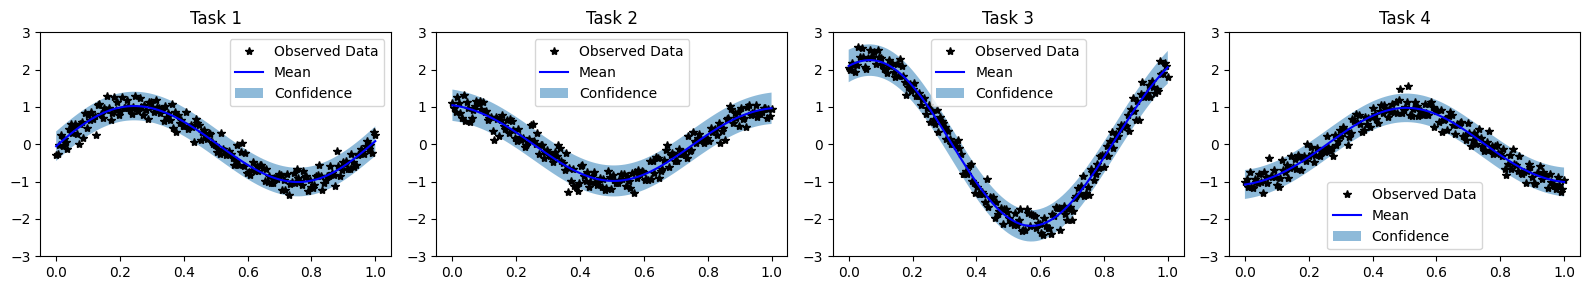

In [1]:
import math
import torch
import gpytorch
import tqdm
from matplotlib import pyplot as plt

# トレーニングデータを作成
# 4つの異なるタスク（今回はすべてsin/cosベースの関数）を持つ
train_x = torch.linspace(0, 1, 200)
train_y = torch.stack([
    torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * 0.2,
    torch.cos(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * 0.2,
    torch.sin(train_x * (2 * math.pi)) + 2 * torch.cos(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * 0.2,
    -torch.cos(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * 0.2,
], -1)

# CUDAが利用可能な場合はGPUを使用
if torch.cuda.is_available():
    train_x, train_y = train_x.cuda(), train_y.cuda()

# --- モデルの定義 ---
# 自然勾配法を用いるマルチタスクGPモデル
num_latents = 3  # 潜在関数の数
num_tasks = 4    # タスクの数

class MultitaskGPModelWithNGD(gpytorch.models.ApproximateGP):
    def __init__(self, num_latents, num_tasks):
        # 各潜在関数に対応する誘導点を設定
        inducing_points = torch.rand(num_latents, 32, 1)
        if torch.cuda.is_available():
            inducing_points = inducing_points.cuda()

        # 自然勾配法用の変分分布を使用
        variational_distribution = gpytorch.variational.NaturalVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_latents])
        )

        # LMC変分戦略でラップ
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
            num_tasks=num_tasks,
            num_latents=num_latents,
            latent_dim=-1
        )

        super().__init__(variational_strategy)

        # 平均と共分散モジュールをバッチ対応にする
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# モデルと尤度のインスタンス化
model = MultitaskGPModelWithNGD(num_latents=num_latents, num_tasks=num_tasks)
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()


# --- 訓練プロセス ---
model.train()
likelihood.train()

# 2種類のオプティマイザを設定
# 1. 変分パラメータのための自然勾配オプティマイザ
variational_optimizer = gpytorch.optim.NGD(model.variational_parameters(), num_data=train_y.size(0), lr=0.1)
# 2. ハイパーパラメータのためのAdamオプティマイザ
hyperparameter_optimizer = torch.optim.Adam([
    {'params': model.hyperparameters()},
    {'params': likelihood.parameters()},
], lr=0.01)

# 損失関数
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))

# 訓練ループ
num_epochs = 1000
epochs_iter = tqdm.tqdm(range(num_epochs), desc="Epoch")

for i in epochs_iter:
    variational_optimizer.zero_grad()
    hyperparameter_optimizer.zero_grad()
    
    output = model(train_x)
    loss = -mll(output, train_y)
    
    epochs_iter.set_postfix(loss=loss.item())
    loss.backward()
    
    variational_optimizer.step()
    hyperparameter_optimizer.step()

# --- 予測と可視化 ---
model.eval()
likelihood.eval()

# テストデータを作成
test_x = torch.linspace(0, 1, 101)
if torch.cuda.is_available():
    test_x = test_x.cuda()

# グラフを初期化
fig, axs = plt.subplots(1, num_tasks, figsize=(4 * num_tasks, 3))

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(test_x))
    mean = predictions.mean
    lower, upper = predictions.confidence_region()

# CPUにデータを移動してプロット
train_x = train_x.cpu()
train_y = train_y.cpu()
test_x = test_x.cpu()
mean = mean.cpu()
lower = lower.cpu()
upper = upper.cpu()

for task, ax in enumerate(axs):
    ax.plot(train_x.numpy(), train_y[:, task].numpy(), 'k*', label='Observed Data')
    ax.plot(test_x.numpy(), mean[:, task].numpy(), 'b', label='Mean')
    ax.fill_between(test_x.numpy(), lower[:, task].numpy(), upper[:, task].numpy(), alpha=0.5, label='Confidence')
    ax.set_ylim([-3, 3])
    ax.set_title(f'Task {task + 1}')
    ax.legend()

fig.tight_layout()
plt.show()